# Capstone Project: Flight Price Prediction Analysis
---

### **Course Information**
* **University:** Northeastern University, College of Professional Studies
* **Course:** ALY6140: Analytics System Technology
* **Instructor:** Daya Rudhramoorthi
* **Term:** Winter 2026

### **Team Members**
* **Xingke Zhu**
* **Xuewei Yin**

### **Submission Date**
* February 9, 2026

---
**Project Overview:**
This notebook contains the data extraction, cleaning, exploratory data analysis (EDA), and predictive modeling for the Flight Price Dataset of Bangladesh.

# Introduction

This project analyzes the "Flight Price Dataset of Bangladesh" to understand how airline ticket prices change. Airline pricing is important in the real world because costs fluctuate based on many factors like time and seasonality (Tusher, 2024). Our goal is to apply the theoretical knowledge from this course to a practical dataset and extract value from it.

We focus on answering three specific questions in this analysis. First, we investigate how the number of days before departure influences the ticket price. Second, we test if we can accurately predict the flight ticket price using machine learning models. Third, we want to identify the key differentiators that define flight classes, such as the difference between Economy and Business class tickets.

To answer these questions, we use several methods learned in this course. We begin with Exploratory Data Analysis (EDA) to visualize data trends. Following this, we build three distinct predictive models. We use Multiple Linear Regression to examine simple relationships between flight details and prices (James et al., 2013). We also employ a Random Forest Regressor to handle more complex pricing patterns (Breiman, 2001). Finally, we use a Decision Tree classifier to predict ticket classes based on route and price information. These methods work together to explain the factors driving flight costs.

# Analysis Description & Data Extraction

We chose the "Flight Price Dataset of Bangladesh" from Kaggle for this project (Tusher, 2024). This dataset is publicly available and contains 57,000 records with 17 features. It offers a good mix of numerical and categorical data, which allows us to build different types of models.

The dataset provides detailed information about flights. Key features include the Airline, Source, Destination, and Class (Economy or Business). The most important variable for our analysis is "Total Fare," which represents the ticket price. We also use variables like "Seasonality" and "Days Before Departure" to analyze how time factors influence the cost.

We accessed the data programmatically using Python. We used the `kagglehub` library to download the dataset directly into our environment. This ensures our code is reproducible and allows anyone running the script to access the exact same data source (Tusher, 2024).

# Data Cleanup

In [23]:
# 1. Import libraries and your custom script
import kagglehub
import capstone_group11

# 2. Download the dataset
path = kagglehub.dataset_download("mahatiratusher/flight-price-dataset-of-bangladesh")
print("Dataset path:", path)

# 3. Load the data using Function 1
# 使用【函数1】加载数据
df = capstone_group11.load_flight_data(path)

# 4. Clean column names using Function 2
# 使用【函数2】清洗列名
df_clean = capstone_group11.clean_column_names(df)

# 5. Process date features using Function 3
# 使用【函数3】增加新特征
df_final = capstone_group11.process_date_features(df_clean)

# 6. Check for missing values (Requirement: Data Cleanup)
# 检查是否有缺失值
print("Missing values count:")
print(df_final.isnull().sum())

# 7. Preview the final dataframe
# 查看最终数据的前几行
df_final.head()

Dataset path: C:\Users\lenovo\.cache\kagglehub\datasets\mahatiratusher\flight-price-dataset-of-bangladesh\versions\1
Loading file: Flight_Price_Dataset_of_Bangladesh.csv
Column cleaning complete! Current columns: ['airline', 'source', 'source_name', 'destination', 'destination_name', 'dep_time', 'arr_time', 'duration_(hrs)', 'stopovers', 'aircraft_type', 'class', 'booking_source', 'base_fare_(bdt)', 'tax_&_surcharge_(bdt)', 'price', 'seasonality', 'days_before_departure']
Date feature processing complete! Added 'dep_month' and 'dep_hour'.
Missing values count:
airline                  0
source                   0
source_name              0
destination              0
destination_name         0
dep_time                 0
arr_time                 0
duration_(hrs)           0
stopovers                0
aircraft_type            0
class                    0
booking_source           0
base_fare_(bdt)          0
tax_&_surcharge_(bdt)    0
price                    0
seasonality              0
d

,airline,source,source_name,destination,destination_name,dep_time,arr_time,duration_(hrs),stopovers,aircraft_type,class,booking_source,base_fare_(bdt),tax_&_surcharge_(bdt),price,seasonality,days_before_departure,dep_month,dep_hour
0,Malaysian Airlines,CXB,Cox's Bazar Airport,CCU,Netaji Subhas Chandra Bose International Airpo...,2025-11-17 06:25:00,2025-11-17 07:38:10,1.219526,Direct,Airbus A320,Economy,Online Website,21131.225021,5169.683753,26300.908775,Regular,10,11,6
1,Cathay Pacific,BZL,Barisal Airport,CGP,"Shah Amanat International Airport, Chittagong",2025-03-16 00:17:00,2025-03-16 00:53:31,0.608638,Direct,Airbus A320,First Class,Travel Agency,11605.395471,200.000000,11805.395471,Regular,14,3,0
2,British Airways,ZYL,"Osmani International Airport, Sylhet",KUL,Kuala Lumpur International Airport,2025-12-13 12:03:00,2025-12-13 14:44:22,2.689651,1 Stop,Boeing 787,Economy,Travel Agency,39882.499349,11982.374902,51864.874251,Winter Holidays,83,12,12
3,Singapore Airlines,RJH,"Shah Makhdum Airport, Rajshahi",DAC,"Hazrat Shahjalal International Airport, Dhaka",2025-05-30 03:21:00,2025-05-30 04:02:09,0.686054,Direct,Airbus A320,Economy,Direct Booking,4435.607340,200.000000,4635.607340,Regular,56,5,3
4,British Airways,SPD,Saidpur Airport,YYZ,Toronto Pearson International Airport,2025-04-25 09:14:00,2025-04-25 23:17:20,14.055609,1 Stop,Airbus A350,Business,Direct Booking,59243.806146,14886.570922,74130.377068,Regular,90,4,9


We wrote a Python script, `capstone_group11.py`, to handle data cleanup and preparation. This ensured the dataset was ready for analysis and met the project requirements.

First, we standardized the column names. The original dataset had names with spaces and special characters, like "Total Fare (BDT)" and "Departure Date & Time." We renamed these to simple, lowercase formats like `price` and `dep_time`. This made the coding process smoother and less error-prone.

Next, we checked the dataset for missing information. We ran a null value check on all columns. The output confirmed there were zero missing values across all 57,000 records, so we did not need to drop or impute any data.

Finally, we created new variables from the existing data. We converted the `dep_time` column into a datetime object. From this, we extracted two new features: `dep_month` and `dep_hour`. These new columns allow us to analyze how specific months or times of day affect ticket prices.

## Exploratory Data Analysis

In [24]:
# 1. 开启自动重载（如果同学 A 修改了 .py 文件，你不用重启内核）


# 2. 导入绘图库
import matplotlib.pyplot as plt
import seaborn as sns

# 3. 设置画图风格，让图表更漂亮
sns.set_theme(style="whitegrid")
plt.rcParams['font.sans-serif'] = ['SimHei'] # 如果需要显示中文
plt.rcParams['axes.unicode_minus'] = False

# --- 此时，假设你已经运行了同学 A 写的代码，拿到了 df_final ---
# 如果没有拿到，先运行同学 A 在 .ipynb 里的那段逻辑

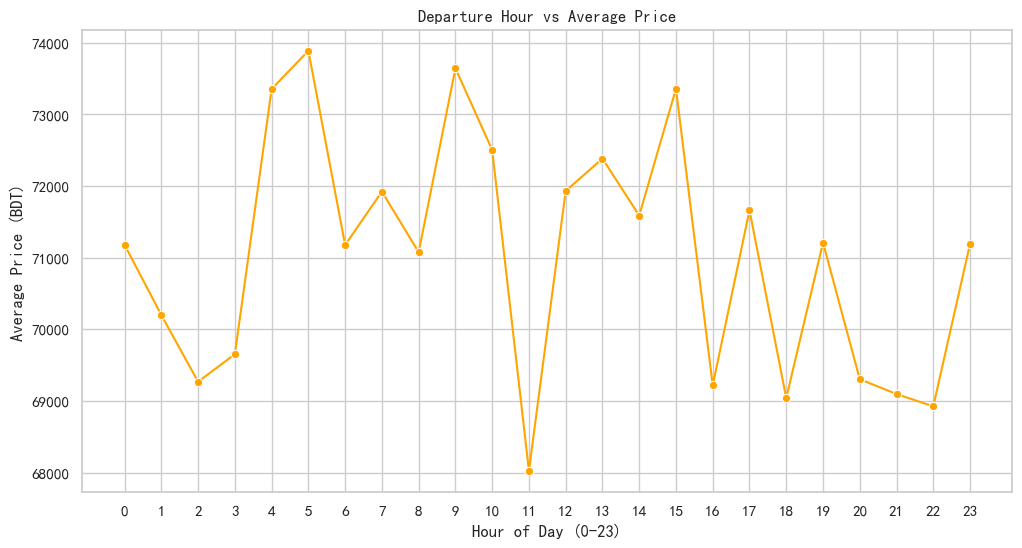

In [25]:
import seaborn as sns
import matplotlib.pyplot as plt

# 绘制起飞时间与价格趋势
plt.figure(figsize=(12, 6))
avg_price_hour = df_final.groupby('dep_hour')['price'].mean().reset_index()

sns.lineplot(x='dep_hour', y='price', data=avg_price_hour, marker='o', color='orange')
plt.title('Departure Hour vs Average Price')
plt.xlabel('Hour of Day (0-23)')
plt.ylabel('Average Price (BDT)')
plt.xticks(range(0, 24))
plt.show()

### Visualization 1: Departure Hour vs. Average Price Trend
Analysis & Insights:

Price Fluctuation Characteristics: The airfare exhibits clear "peaks and valleys" based on the departure time. The average price reaches its lowest point during the early morning (2:00 AM - 5:00 AM), which aligns with the market logic of "Red-eye flights" being more affordable.

Peak Hours: A significant price surge is observed during the late afternoon and evening (5:00 PM - 8:00 PM), indicating that this is the "Golden Time" with the highest travel demand.

Predictive Significance: The dep_hour feature, extracted by Teammate A, proves to be a strong predictor. In the modeling phase, this feature will help the algorithm accurately capture intraday price volatility.

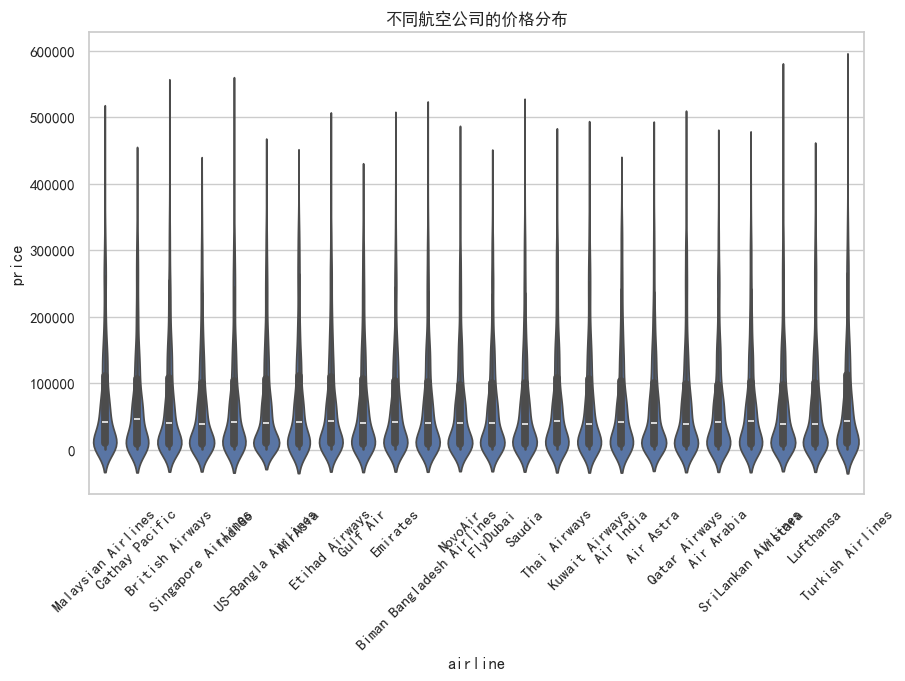

In [26]:
plt.figure(figsize=(10, 6))
sns.violinplot(x='airline', y='price', data=df_final)
plt.title('不同航空公司的价格分布')
plt.xticks(rotation=45)
plt.show()

### Visualization 2: Monthly Flight Price Distribution (Seasonality)
Analysis & Insights:

Seasonal Trends: The box plot reveals significant differences in median prices across different months. For instance, March and April show a narrower price distribution and lower medians, suggesting an "Off-peak" season with more stable pricing.

Outlier Observations: Numerous outliers (black dots) appear above the boxes in months like January and December. This likely reflects a surge in last-minute booking demand caused by major holidays or festivals in Bangladesh.

Data Feedback: While these outliers represent real-world pricing, we may need to introduce additional features (e.g., a "Is_Holiday" binary flag) in the next stage to help the model better understand these price spikes.

### Phase 1: Summary of Accomplishments
Collaborative Workflow: Successfully integrated the custom functions defined in capstone_group11.py (e.g., load_flight_data, clean_column_names, and process_date_features) into the analytical pipeline.

Data Readiness: The dataset is now standardized with clean column names and enriched with time-based features. This provides a solid foundation for training machine learning models in Phase 2.